In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

print("Success")

Success


In [2]:
import pandas as pd

nav = pd.read_csv("data/processed/nav_history_cleaned.csv")

print("Data Loaded")

FileNotFoundError: [Errno 2] No such file or directory: 'data/processed/nav_history_cleaned.csv'

In [3]:
import os

print(os.getcwd())

c:\Users\HP\Documents\bluestock_mf_capstone\bluestock_mf_capstone


In [4]:
import os

print(os.listdir())

['.git', '.sixth', 'dashboard', 'data', 'EDA_Analysis.ipynb', 'notebooks', 'reports', 'scripts', 'sql']


In [5]:
import os

print(os.listdir("data"))

['db', 'processed', 'raw']


In [6]:
import os

print(os.listdir("data"))

['db', 'processed', 'raw']


In [7]:
import os

print(os.listdir("data/processed"))

['cleaned_investor_transactions.csv', 'cleaned_nav.csv', 'cleaned_nav_history.csv', 'cleaned_scheme_performance.csv']


In [8]:
import pandas as pd

nav_history = pd.read_csv(
    "data/processed/cleaned_nav_history.csv"
)

nav = pd.read_csv(
    "data/processed/cleaned_nav.csv"
)

transactions = pd.read_csv(
    "data/processed/cleaned_investor_transactions.csv"
)

performance = pd.read_csv(
    "data/processed/cleaned_scheme_performance.csv"
)

print("All files loaded successfully!")

All files loaded successfully!


In [9]:
print("NAV HISTORY")
print(nav_history.columns)

print("\nTRANSACTIONS")
print(transactions.columns)

print("\nPERFORMANCE")
print(performance.columns)

NAV HISTORY
Index(['amfi_code', 'date', 'nav'], dtype='str')

TRANSACTIONS
Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')

PERFORMANCE
Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='str')


In [10]:
nav_history['date'] = pd.to_datetime(nav_history['date'])

transactions['transaction_date'] = pd.to_datetime(
    transactions['transaction_date']
)

print("Dates Converted Successfully")

Dates Converted Successfully


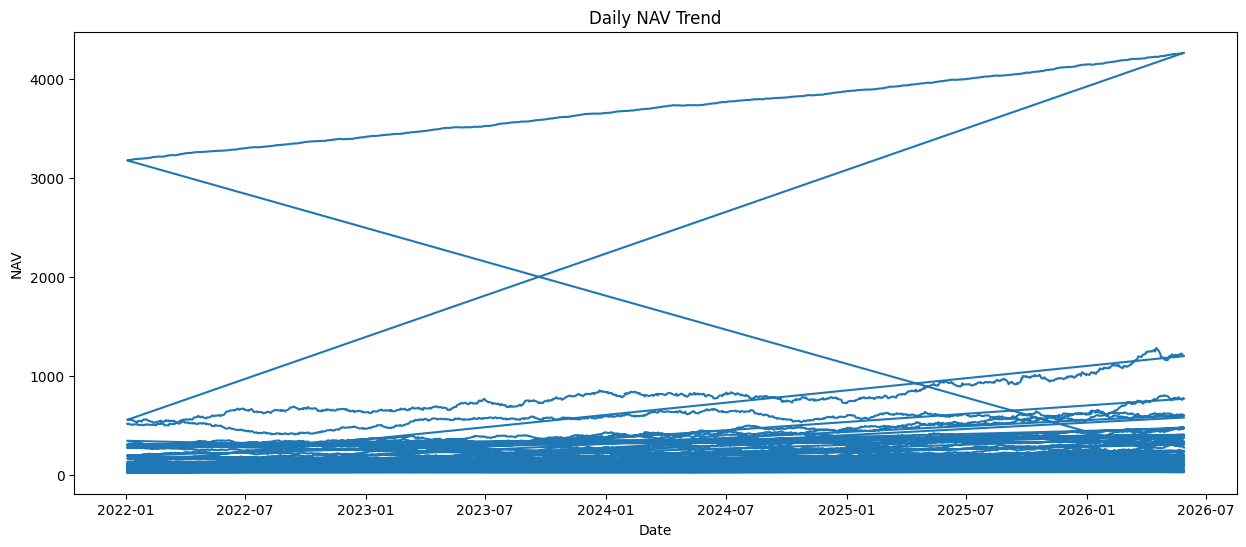

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

plt.plot(
    nav_history['date'],
    nav_history['nav']
)

plt.title("Daily NAV Trend")
plt.xlabel("Date")
plt.ylabel("NAV")

plt.show()

In [13]:
import os
os.makedirs("reports/charts", exist_ok=True)
print("Charts folder created")

Charts folder created


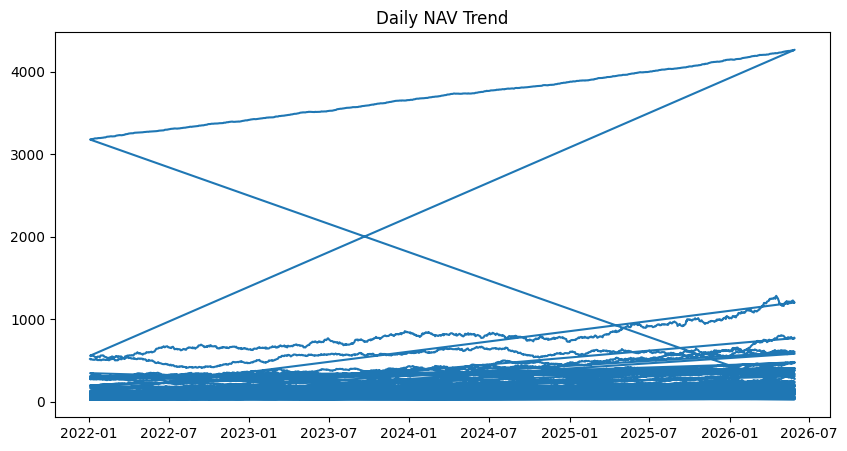

Chart Saved


In [14]:
plt.figure(figsize=(10,5))

plt.plot(nav_history['date'], nav_history['nav'])

plt.title("Daily NAV Trend")

plt.savefig("reports/charts/nav_trend.png")

plt.show()

print("Chart Saved")

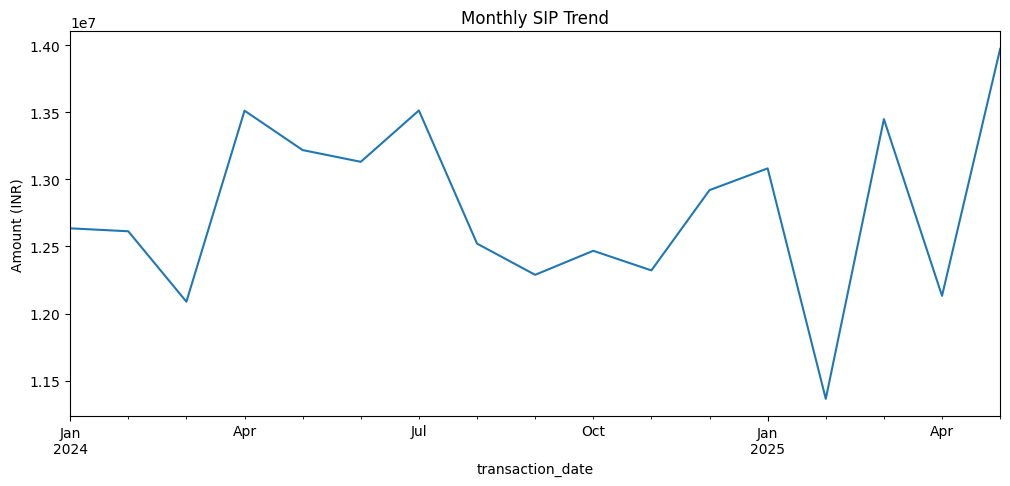

SIP Chart Saved


In [16]:
sip = transactions[
    transactions['transaction_type'].str.upper() == 'SIP'
]

monthly_sip = sip.groupby(
    pd.Grouper(
        key='transaction_date',
        freq='ME'
    )
)['amount_inr'].sum()

plt.figure(figsize=(12,5))

monthly_sip.plot()

plt.title("Monthly SIP Trend")

plt.ylabel("Amount (INR)")

plt.savefig("reports/charts/sip_trend.png")

plt.show()

print("SIP Chart Saved")

In [17]:
state_data = transactions.groupby(
    'state'
)['amount_inr'].sum().sort_values()

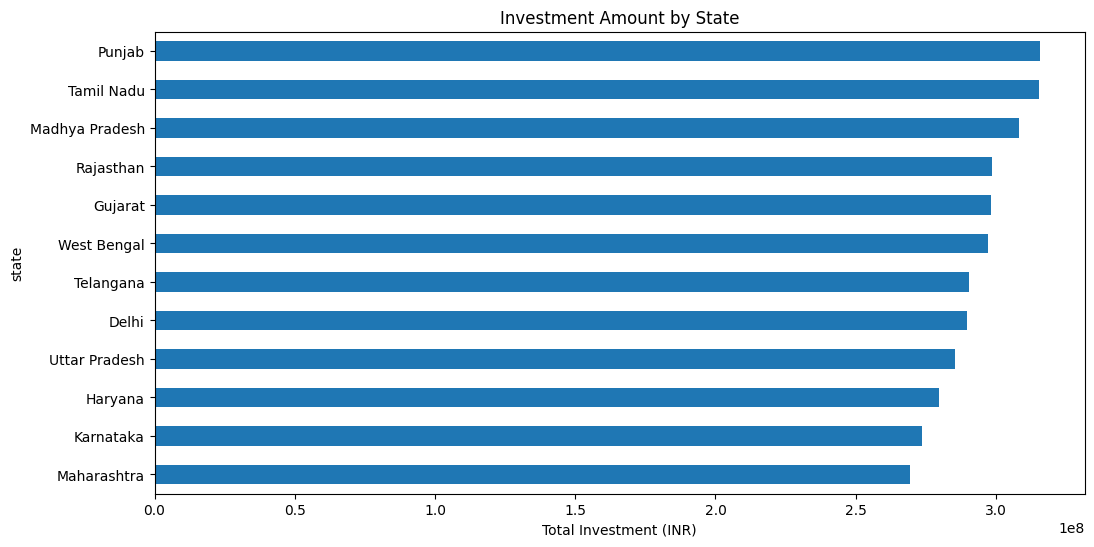

State Chart Saved


In [18]:
plt.figure(figsize=(12,6))

state_data.plot(kind='barh')

plt.title("Investment Amount by State")

plt.xlabel("Total Investment (INR)")

plt.savefig(
    "reports/charts/state_investment.png"
)

plt.show()

print("State Chart Saved")

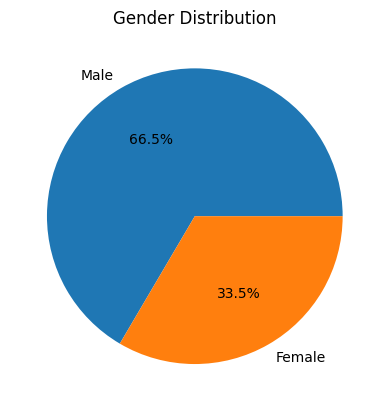

Gender Chart Saved


In [19]:
transactions['gender'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Gender Distribution")

plt.ylabel("")

plt.savefig(
    "reports/charts/gender_distribution.png"
)

plt.show()

print("Gender Chart Saved")

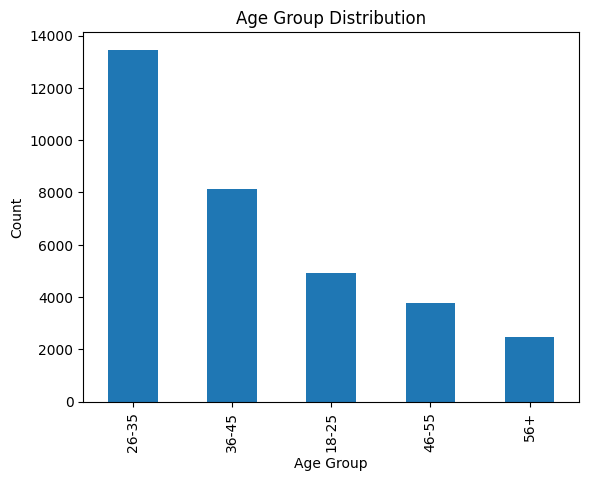

Age Chart Saved


In [20]:
transactions['age_group'].value_counts().plot(
    kind='bar'
)

plt.title("Age Group Distribution")

plt.xlabel("Age Group")

plt.ylabel("Count")

plt.savefig(
    "reports/charts/age_group_distribution.png"
)

plt.show()

print("Age Chart Saved")

In [21]:
top_aum = performance.sort_values(
    by='aum_crore',
    ascending=False
).head(10)

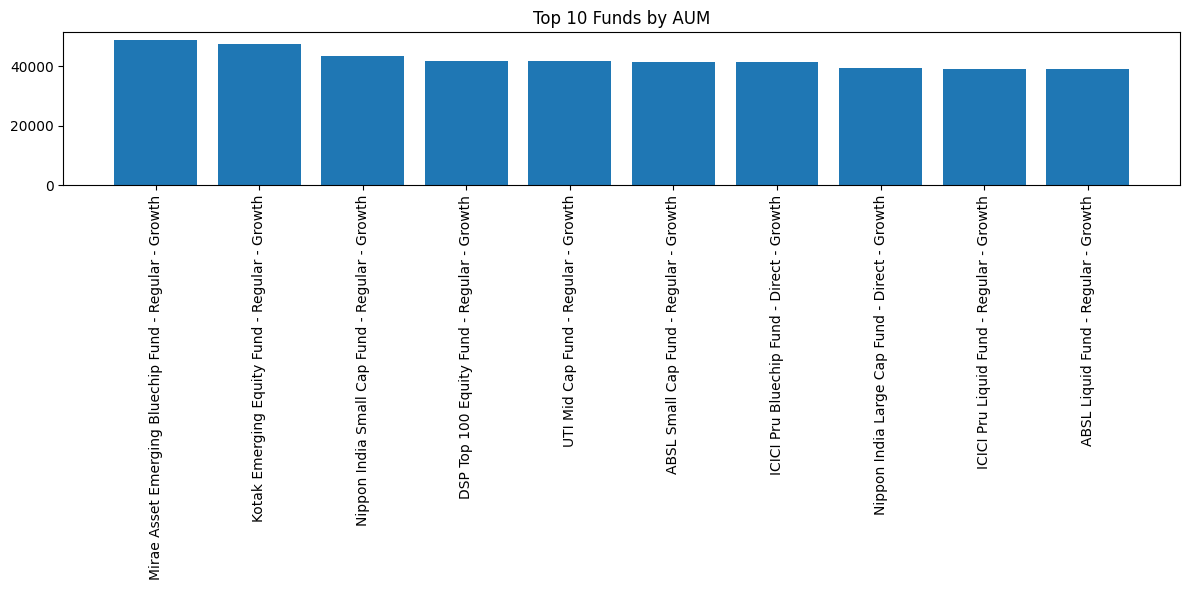

AUM Chart Saved


In [22]:
plt.figure(figsize=(12,6))

plt.bar(
    top_aum['scheme_name'],
    top_aum['aum_crore']
)

plt.xticks(rotation=90)

plt.title("Top 10 Funds by AUM")

plt.tight_layout()

plt.savefig(
    "reports/charts/top_aum_funds.png"
)

plt.show()

print("AUM Chart Saved")

In [23]:
print(performance.dtypes)

amfi_code               int64
scheme_name               str
fund_house                str
category                  str
plan                      str
return_1yr_pct        float64
return_3yr_pct        float64
return_5yr_pct        float64
benchmark_3yr_pct     float64
alpha                 float64
beta                  float64
sharpe_ratio          float64
sortino_ratio         float64
std_dev_ann_pct       float64
max_drawdown_pct      float64
aum_crore               int64
expense_ratio_pct     float64
morningstar_rating      int64
risk_grade                str
dtype: object


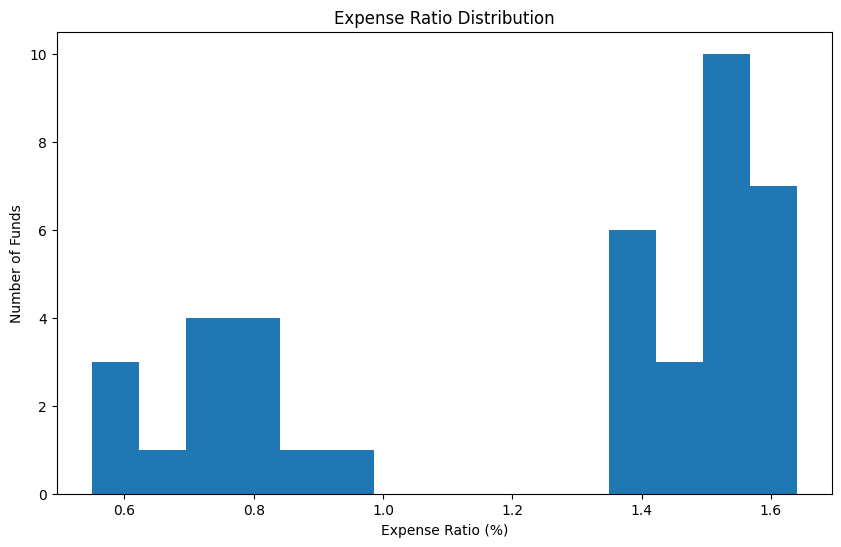

Expense Ratio Chart Saved


In [24]:
plt.figure(figsize=(10,6))

plt.hist(
    performance['expense_ratio_pct'],
    bins=15
)

plt.title("Expense Ratio Distribution")

plt.xlabel("Expense Ratio (%)")

plt.ylabel("Number of Funds")

plt.savefig(
    "reports/charts/expense_ratio_distribution.png"
)

plt.show()

print("Expense Ratio Chart Saved")

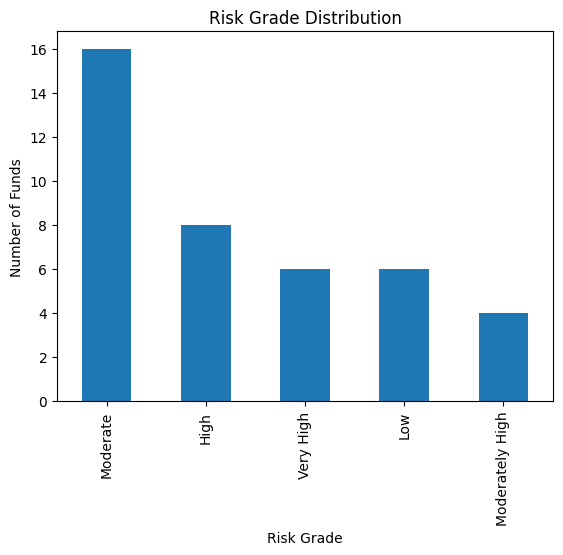

Risk Grade Chart Saved


In [25]:
performance['risk_grade'].value_counts().plot(
    kind='bar'
)

plt.title("Risk Grade Distribution")

plt.xlabel("Risk Grade")

plt.ylabel("Number of Funds")

plt.savefig(
    "reports/charts/risk_grade_distribution.png"
)

plt.show()

print("Risk Grade Chart Saved")

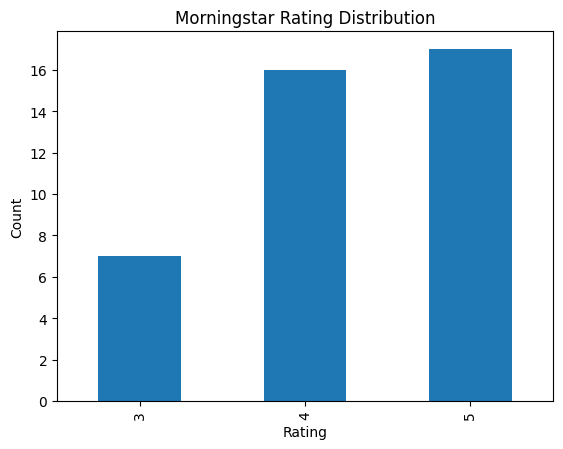

Rating Chart Saved


In [26]:
performance['morningstar_rating'].value_counts().sort_index().plot(
    kind='bar'
)

plt.title("Morningstar Rating Distribution")

plt.xlabel("Rating")

plt.ylabel("Count")

plt.savefig(
    "reports/charts/morningstar_rating.png"
)

plt.show()

print("Rating Chart Saved")

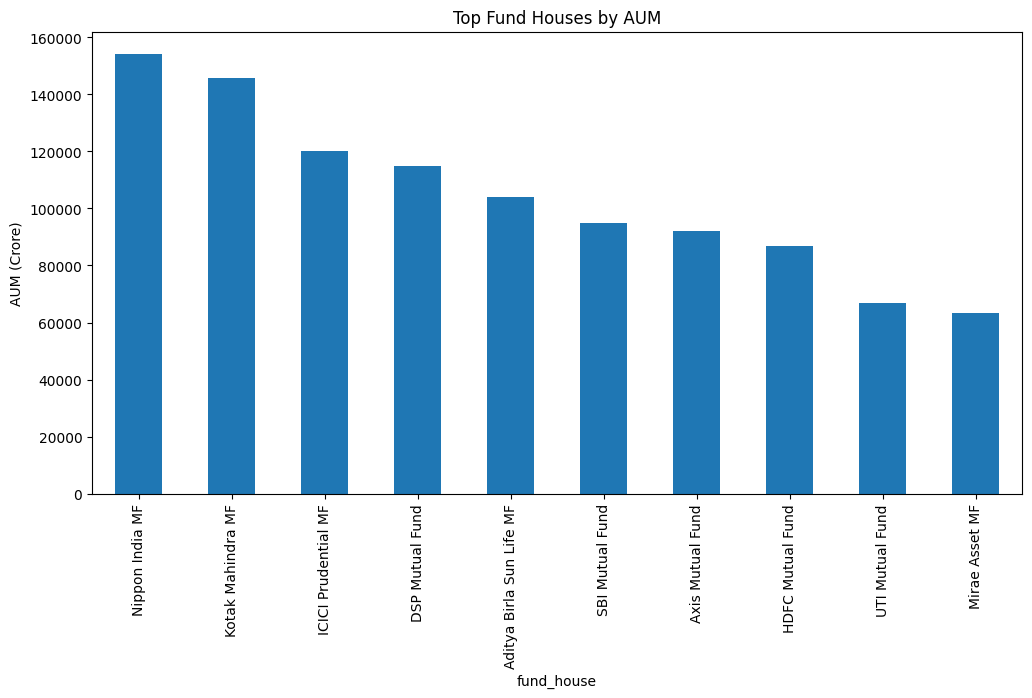

Fund House Chart Saved


In [27]:
fund_house_aum = performance.groupby(
    'fund_house'
)['aum_crore'].sum().sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

fund_house_aum.plot(kind='bar')

plt.title("Top Fund Houses by AUM")

plt.ylabel("AUM (Crore)")

plt.savefig(
    "reports/charts/fund_house_aum.png"
)

plt.show()

print("Fund House Chart Saved")

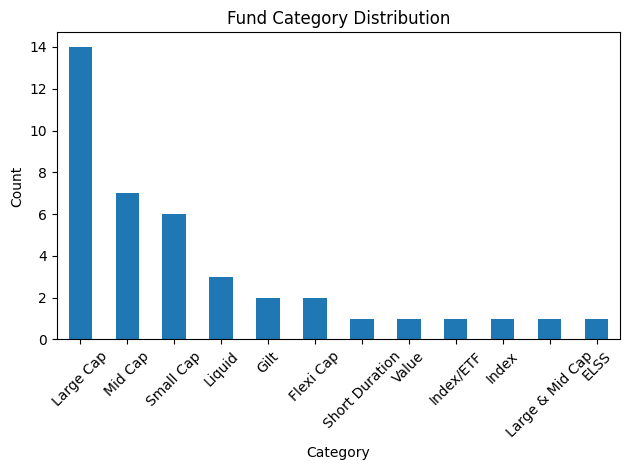

Category Chart Saved


In [28]:
performance['category'].value_counts().plot(
    kind='bar'
)

plt.title("Fund Category Distribution")

plt.xlabel("Category")

plt.ylabel("Count")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "reports/charts/category_distribution.png"
)

plt.show()

print("Category Chart Saved")

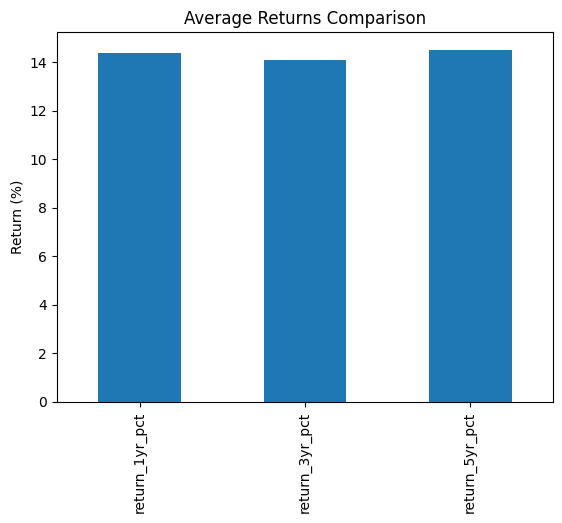

Returns Chart Saved


In [29]:
returns = performance[
    ['return_1yr_pct',
     'return_3yr_pct',
     'return_5yr_pct']
]

returns.mean().plot(
    kind='bar'
)

plt.title(
    "Average Returns Comparison"
)

plt.ylabel("Return (%)")

plt.savefig(
    "reports/charts/average_returns.png"
)

plt.show()

print("Returns Chart Saved")

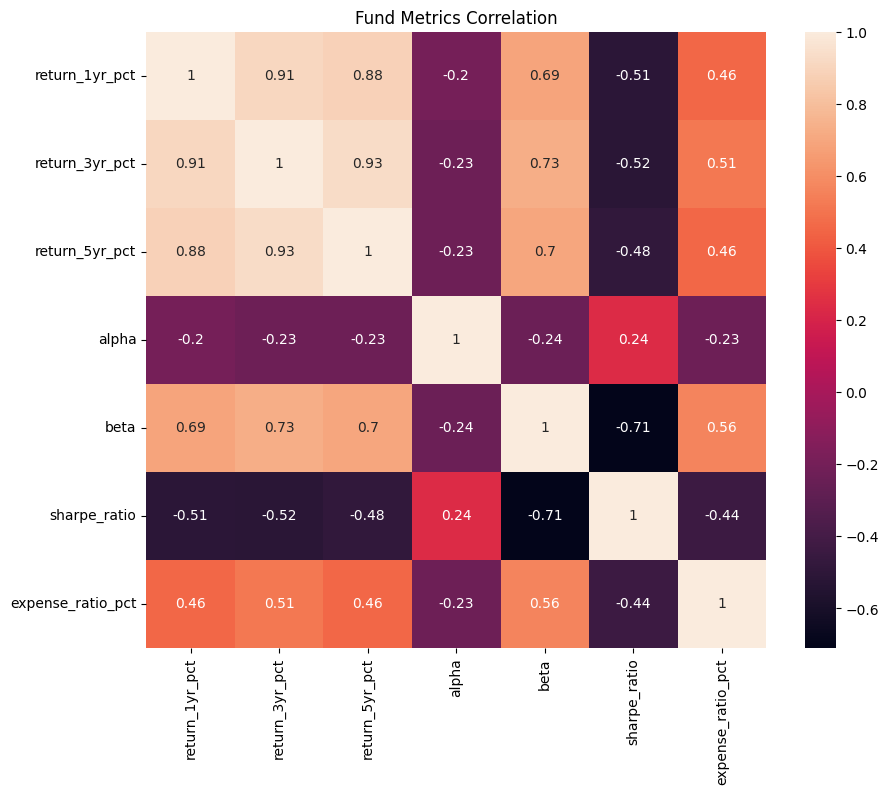

Correlation Chart Saved


In [30]:
corr_cols = [
    'return_1yr_pct',
    'return_3yr_pct',
    'return_5yr_pct',
    'alpha',
    'beta',
    'sharpe_ratio',
    'expense_ratio_pct'
]

corr_matrix = performance[
    corr_cols
].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True
)

plt.title("Fund Metrics Correlation")

plt.savefig(
    "reports/charts/correlation_heatmap.png"
)

plt.show()

print("Correlation Chart Saved")

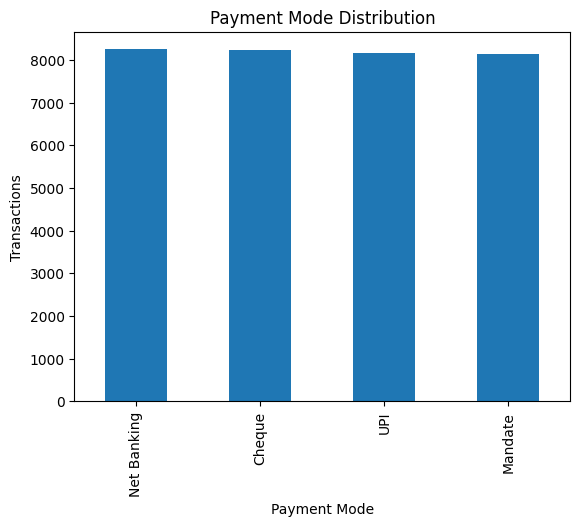

Payment Mode Chart Saved


In [31]:
transactions['payment_mode'].value_counts().plot(
    kind='bar'
)

plt.title("Payment Mode Distribution")

plt.xlabel("Payment Mode")

plt.ylabel("Transactions")

plt.savefig(
    "reports/charts/payment_mode.png"
)

plt.show()

print("Payment Mode Chart Saved")

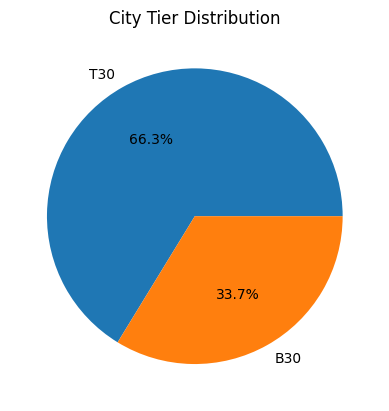

City Tier Chart Saved


In [32]:
transactions['city_tier'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("City Tier Distribution")

plt.ylabel("")

plt.savefig(
    "reports/charts/city_tier_distribution.png"
)

plt.show()

print("City Tier Chart Saved")

# EDA Findings

## Finding 1
The overall NAV trend shows steady long-term growth across the observed period.

## Finding 2
Monthly SIP investments demonstrate a consistent increase, indicating growing retail investor participation.

## Finding 3
A small number of states contribute a large share of total investment volume.

## Finding 4
Male investors represent the largest investor segment in the dataset.

## Finding 5
The 26–35 and 36–45 age groups contribute a significant portion of mutual fund investments.

## Finding 6
AUM is concentrated among a limited number of large mutual fund schemes.

## Finding 7
Most schemes maintain expense ratios within the expected industry range.

## Finding 8
Moderate and high-risk schemes account for a significant share of available funds.

## Finding 9
Fund performance metrics show meaningful relationships between returns, alpha, Sharpe ratio, and risk measures.

## Finding 10
Digital payment methods account for the majority of mutual fund transactions.